In [1]:
import sys
from pathlib import Path

# Add the parent directory to sys.path
parent_path = Path().resolve().parent
if str(parent_path) not in sys.path:
    sys.path.append(str(parent_path))

In [4]:
from pyhgf.model import Network
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pytensor.tensor as pt
import pymc as pm
from scipy.stats import norm
from pathlib import Path
import jax.numpy as jnp
from jax.scipy.stats import norm
from pyhgf.math import binary_surprise
from models.utils import extract_psychometric, cumulative_normal
from distributions import get_cardioception_hgf
from jax import config

config.update("jax_enable_x64", True)

plt.rcParams["figure.constrained_layout.use"] = True

In [6]:
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
hrd_df = hrd_df[hrd_df.task == "hrd-session2"]

In [7]:
participant_id = "sub-0127"
df = hrd_df[hrd_df.participant_id == participant_id]
df.head()

,participant_id,id,task,cohort,StaircaseType,Condition,Modality,Decision,DecisionRT,Confidence,...,nTrials,EstimatedThreshold,EstimatedSlope,StartListening,StartDecision,ResponseMade,RatingStart,RatingEnds,endTrigger,session
25881,sub-0127,127,hrd-session2,vmp1,psi,Less,Intero,NaN,NaN,NaN,...,0,22.805550,12.549457,1.602849e+09,1.602849e+09,1.602849e+09,NaN,NaN,1.602849e+09,2
25882,sub-0127,127,hrd-session2,vmp1,psi,Less,Extero,More,2.099876,30.0,...,1,-23.245423,12.550553,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25883,sub-0127,127,hrd-session2,vmp1,psi,More,Intero,More,1.599438,100.0,...,2,10.001882,12.884902,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25884,sub-0127,127,hrd-session2,vmp1,psi,More,Intero,More,4.282859,43.0,...,3,0.998384,13.044744,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2
25885,sub-0127,127,hrd-session2,vmp1,psi,Less,Intero,More,2.832672,25.0,...,4,-8.641712,15.504796,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,1.602849e+09,2


In [8]:
heart_rate = df[df.Modality == "Intero"].listenBPM.to_numpy()
intero_tone_2 = df[df.Modality == "Intero"].responseBPM.to_numpy()
extero_tone_1 = df[df.Modality == "Extero"].listenBPM.to_numpy()
extero_tone_2 = df[df.Modality == "Extero"].responseBPM.to_numpy()

extero_decision = (df[df.Modality == "Extero"].Decision.to_numpy() == "More").astype(
    int
)
intero_decision = (df[df.Modality == "Intero"].Decision.to_numpy() == "More").astype(
    int
)

## Predictive coding

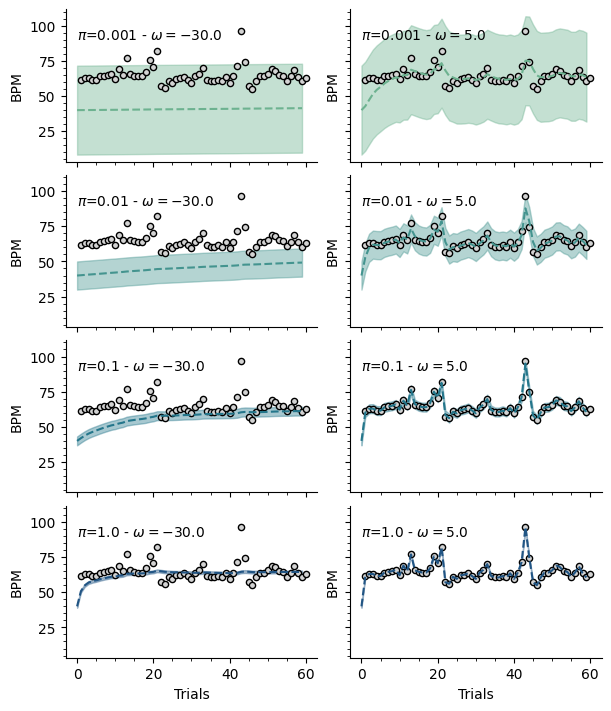

In [10]:
_, axs = plt.subplots(figsize=(6, 7), nrows=4, ncols=2, sharex=True, sharey=True)

colors = sns.color_palette("crest", n_colors=4)
x = np.arange(0, len(heart_rate))
for i, tonic_volatility in enumerate([-30.0, 5.0]):
    for ii, precision, color in zip(range(5), [0.001, 0.01, 0.1, 1.0], colors):
        network = (
            Network(update_type="unbounded")
            .add_nodes(precision=precision, expected_precision=precision)
            .add_nodes(value_children=0, mean=40.0, tonic_volatility=tonic_volatility)
        )

        network.input_data(input_data=heart_rate)
        std = np.sqrt(1 / network.node_trajectories[0]["expected_precision"])
        axs[ii, i].fill_between(
            x=x,
            y1=network.node_trajectories[0]["expected_mean"] - std,
            y2=network.node_trajectories[0]["expected_mean"] + std,
            color=color,
            alpha=0.4,
        )
        axs[ii, i].plot(
            x,
            network.node_trajectories[0]["expected_mean"],
            linestyle="--",
            color=color,
        )

        axs[ii, i].scatter(
            np.arange(1, len(heart_rate) + 1),
            heart_rate,
            s=20,
            color="lightgrey",
            edgecolor="k",
        )

        axs[ii, i].text(
            0, 90, rf"$\pi$={precision} - $\omega = {tonic_volatility}$", fontsize=10
        )

        axs[ii, i].set(ylabel="BPM")
        axs[ii, i].minorticks_on()

axs[-1, 0].set(xlabel="Trials")
axs[-1, 1].set(xlabel="Trials")
sns.despine()
# plt.savefig(Path().cwd().parent.parent / "figures" / "fig_4_hgf_precision.svg")